# DeepSeek OCR Fine-tuning Notebook

This notebook demonstrates how to fine-tune the DeepSeek OCR model using Unsloth for improved optical character recognition on medieval manuscripts.

## Overview
- Load and configure the DeepSeek OCR model
- Prepare the CATMuS medieval dataset
- Evaluate the model before fine-tuning (baseline)
- Fine-tune using LoRA (Low-Rank Adaptation)
- Evaluate the model after fine-tuning
- Compare performance using Character Error Rate (CER)

## 1. Import Required Libraries

Import all necessary libraries for:
- Model loading and training (Unsloth, Transformers)
- Data processing (datasets, PIL)
- Evaluation metrics (jiwer for CER calculation)
- Progress tracking (tqdm, pandas)

In [1]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch
from transformers import AutoModel, Trainer, TrainingArguments

from datasets import load_dataset

import math
from dataclasses import dataclass
from typing import Dict, List, Any, Tuple
from PIL import Image, ImageOps
from torch.nn.utils.rnn import pad_sequence
import io


from unsloth import is_bf16_supported

import os

from deepseek_ocr.modeling_deepseekocr import (
    text_encode,
    BasicImageTransform,
    dynamic_preprocess,
)



from jiwer import cer
from tqdm import tqdm # Progress bar
import pandas as pd

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/home/diego/Documents/clases/procesamiento lenguaje natural/proyecto/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth Zoo will now patch everything to make training faster!


## 2. Load the DeepSeek OCR Model

Loading the pre-trained DeepSeek OCR model from the local directory with optimized settings:
- Using Unsloth for faster training
- Gradient checkpointing enabled for memory efficiency
- Trust remote code for custom model implementation

In [2]:
os.environ["UNSLOTH_WARN_UNINITIALIZED"] = '0'

model, tokenizer = FastVisionModel.from_pretrained(
    "./deepseek_ocr",
    load_in_4bit = False, # Use 4bit to reduce memory use. False for 16bit LoRA.
    auto_model = AutoModel,
    trust_remote_code=True,
    unsloth_force_compile=True,
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.


Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2025.11.4: Fast Deepseekocr patching. Transformers: 4.56.2.
   \\   /|    NVIDIA GeForce RTX 5060 Ti. Num GPUs = 1. Max memory: 15.455 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.


Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Some weights of DeepseekOCRForCausalLM were not initialized from the model checkpoint at ./deepseek_ocr and are newly initialized: ['model.vision_model.embeddings.position_ids']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 3. Load Dataset

Loading the CATMuS medieval manuscript dataset (first 5000 samples) for training.

We save one image (index 1523) separately to test on the same image before and after training.

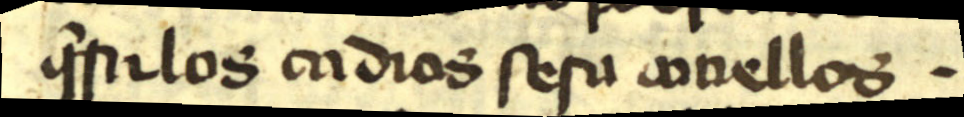

In [3]:

dataset = load_dataset("CATMuS/medieval", split = "train[:5000]")


# Save an image that will not be used during training for evaluation purposes
dataset[1523]['im'].save("your_image.jpg")
dataset[1523]['im']

## 4. Test Original Model on Single Image (Before Fine-tuning)

Let's test the model's OCR capabilities **before** fine-tuning on a single image to establish a baseline.

**Model Configuration:**
- **Gundam settings**: base_size=1024, image_size=640, crop_mode=True
- This configuration balances quality and performance

We'll compare the prediction with the ground truth text from the dataset.

In [4]:
prompt = "<image>\nFree OCR. "
image_file = 'your_image.jpg'
output_path = 'output/baseline'
# infer(self, tokenizer, prompt='', image_file='', output_path = ' ', base_size = 1024, image_size = 640, crop_mode = True, test_compress = False, save_results = False):

# Tiny: base_size = 512, image_size = 512, crop_mode = False
# Small: base_size = 640, image_size = 640, crop_mode = False
# Base: base_size = 1024, image_size = 1024, crop_mode = False
# Large: base_size = 1280, image_size = 1280, crop_mode = False

# Gundam: base_size = 1024, image_size = 640, crop_mode = True

res = model.infer(tokenizer, prompt=prompt, image_file=image_file, output_path = output_path, base_size = 1024, image_size = 640, crop_mode=True, save_results = True, test_compress = False)


print("ground thruth:", dataset[1523]['text'])

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([8, 100, 1280])
fultos fultos andos andos peru peru melleos.
melleos.
===============save results:===============
===============save results:===============


image: 0it [00:00, ?it/s]
image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]

ground thruth: q̈rirlos cadios sera conellos.


## 5. Load Test Dataset Metadata

Load metadata from the local test dataset (200 samples) for comprehensive evaluation.

This will be used to evaluate the model on multiple samples before and after training.

In [5]:
metadata_path = "local_dataset/test/metadata.jsonl"
df = pd.read_json(metadata_path, lines=True)[:200]

### View Test Dataset

Display the test dataset metadata to verify it loaded correctly.

In [6]:
df

,file_name,text,century,language,script_type
0,shard_0000/shard_0000_image_0.png,fazer merçed ⁊ qnt̃o biẽ yo pudiere Et,14,Castilian,Hybrida
1,shard_0000/shard_0000_image_1.png,alguno enla trr̈ã dela ynfanta serin,14,Castilian,Hybrida
2,shard_0000/shard_0000_image_2.png,le rresponderemos ¶Et el ynfante mã,14,Castilian,Hybrida
3,shard_0000/shard_0000_image_3.png,parta de aq̃ fasta q̃ yo uos dexe todo el,14,Castilian,Hybrida
4,shard_0000/shard_0000_image_4.png,q̃ Recabdaredes por lo q̃ ydes muy biẽ,14,Castilian,Hybrida
...,...,...,...,...,...
195,shard_0000/shard_0000_image_195.png,comõ los padres santos fizierõ acada,14,Castilian,Hybrida
196,shard_0000/shard_0000_image_196.png,nõ parando mientes al entẽdimiento,14,Castilian,Hybrida
197,shard_0000/shard_0000_image_197.png,dora /⁊ guardadora dela su casa ꝑo atã,14,Castilian,Hybrida
198,shard_0000/shard_0000_image_198.png,/⁊ fue muy buena dueña /⁊ debuena uida,14,Castilian,Hybrida


## 6. Evaluate Original Model on Test Set (Baseline)

Run comprehensive evaluation on the test dataset **before** fine-tuning.

**Evaluation Process:**
1. Switch model to inference mode
2. Loop through all test samples
3. Run OCR inference on each image
4. Save predictions for later CER calculation

⚠️ **Note:** This will take some time depending on the number of samples and your hardware.

In [7]:


def run_evaluation(model, tokenizer, df, output_path):
    # 1. Enable inference mode
    FastVisionModel.for_inference(model)


    # 2. Select a subset (Eval/Test split)
    # If you have a 'test' split, use that. Otherwise, take a slice of 'train'.
    # We use a slice to avoid waiting hours for the whole dataset.


    print(f"Evaluating on {len(df)} samples...")
    predictions = []

    # 3. Loop through the dataset
    for _, sample in tqdm(df.iterrows(), total=len(df)):

        # Store Ground Truth
        # NOTE: Check your dataset column name. It is usually 'text', 'ground_truth', or 'caption'

        # Run Inference
        # We use the image directly from the dataset (PIL format)
        prediction = model.infer(
            tokenizer,
            prompt = "<image>\nFree OCR. ", 
            image_file = f"local_dataset/test/{sample['file_name']}",
            base_size = 1024, 
            image_size = 640, 
            crop_mode=True, 
            save_results = True, 
            output_path = output_path
            
        )
        # read the saved prediction
        with open(output_path + '/' + "result.mmd", 'r') as f:
            pred_text = f.read().strip()

        predictions.append(pred_text)

    return predictions


predictions_before = run_evaluation(model, tokenizer, df, output_path)



Evaluating on 200 samples...


  0%|          | 0/200 [00:00<?, ?it/s]

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([8, 100, 1280])
fizzer fizzer merci merci (z (z gato gato bic bic yo yo puñerç puñerç at
at
===============save results:===============
===============save results:===============


image: 0it [00:00, ?it/s]
image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]
  0%|          | 1/200 [00:01<03:40,  1.11s/it]

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
alguno alguno en en la la pia pia de de la la yunita yunita Enn
Enn
===============save results:===============
===============save results:===============


...

image: 0it [00:00, ?it/s]
image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]
 99%|█████████▉| 198/200 [09:07<00:01,  1.03it/s]

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
2 Ац муу бична Денда (2 2 Ац муу бична Денда (2 Добуена бида)
===============save results:===============
Добуена бида)
===============save results:===============


image: 0it [00:00, ?it/s]
image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]
100%|█████████▉| 199/200 [09:09<00:01,  1.05s/it]

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
las palabras de la expo  
Ot magnice
las palabras de la expo  
Ot magnice
===============save results:===============
===============save results:===============


image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]
image: 0it [00:00, ?it/s][09:10<00:00,  2.75s/it]
other: 0it [00:00, ?it/s]
100%|██████████| 200/200 [09:10<00:00,  2.75s/it]


## 7. Configure LoRA for Fine-tuning

Setting up LoRA (Low-Rank Adaptation) parameters for efficient fine-tuning:
- **Target modules**: Attention and MLP layers (q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj)
- **Rank (r=16)**: Controls the number of trainable parameters
- **Alpha (16)**: Scaling factor for LoRA weights (recommended: alpha == r)
- **Dropout (0)**: No dropout for stability

LoRA allows us to fine-tune the model efficiently by only training a small subset of parameters.

In [8]:
model = FastVisionModel.get_peft_model(
    model,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

Unsloth: Making `model.base_model.model.model` require gradients


## 8. Prepare Dataset Format

Converting the dataset to the conversation format expected by the model.

Each sample is converted to a conversation with:
- **User role**: Image + prompt ("<image>\nFree OCR. ")
- **Assistant role**: Ground truth text from the manuscript

In [9]:
instruction = "<image>\nFree OCR. "

def convert_to_conversation(sample):
    """Convert dataset sample to conversation format"""
    conversation = [
        {
            "role": "<|User|>",
            "content": instruction,
            "images": [sample['image']]
        },
        {
            "role": "<|Assistant|>",
            "content": sample["text"]
        },
    ]
    return {"messages": conversation}

# Load dataset

dataset = dataset.rename_column("im", "image")

### Convert All Training Samples

Apply the conversion function to all samples in the dataset.

View the first converted sample to verify the format.

In [10]:
converted_dataset = [convert_to_conversation(sample) for sample in dataset]
converted_dataset[0]

{'messages': [{'role': '<|User|>',
   'content': '<image>\nFree OCR. ',
   'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGB size=4772x170>]},
  {'role': '<|Assistant|>',
   'content': 'q̃  y paresçio. ffecha ⁊ signada por man de domĩgo ffeĩrs escrͥuan publico de Burgos del rregistͦ de pͦ m̃z escͥuan. ffizierõ abenẽçia en esta maña q̃los dich̃s Sanch̃ ꝑez ⁊'}]}

## 9. Define Custom Data Collator

The `DeepSeekOCRDataCollator` handles the complex data preprocessing required for vision-language models:

### Key Features:
- **Image Processing**: Handles dynamic cropping and padding based on image size
- **Token Management**: Creates proper token sequences with image placeholders
- **Label Masking**: 
  - Masks padding tokens (-100)
  - Masks image tokens (model shouldn't predict these)
  - Optionally masks user prompts (train only on assistant responses)
- **Batch Collation**: Pads sequences and prepares tensors for the model

### Parameters:
- `image_size=640`: Size for image patches
- `base_size=1024`: Size for global view
- `crop_mode=True`: Use dynamic cropping for large images
- `train_on_responses_only=True`: Only train on assistant responses (recommended)

In [11]:
@dataclass
class DeepSeekOCRDataCollator:
    """
    Args:
        tokenizer: Tokenizer
        model: Model
        image_size: Size for image patches (default: 640)
        base_size: Size for global view (default: 1024)
        crop_mode: Whether to use dynamic cropping for large images
        train_on_responses_only: If True, only train on assistant responses (mask user prompts)
    """
    tokenizer: Any
    model: Any
    image_size: int = 640
    base_size: int = 1024
    crop_mode: bool = True
    image_token_id: int = 128815
    train_on_responses_only: bool = True

    def __init__(
        self,
        tokenizer,
        model,
        image_size: int = 640,
        base_size: int = 1024,
        crop_mode: bool = True,
        train_on_responses_only: bool = True,
    ):
        self.tokenizer = tokenizer
        self.model = model
        self.image_size = image_size
        self.base_size = base_size
        self.crop_mode = crop_mode
        self.image_token_id = 128815
        self.dtype = model.dtype  # Get dtype from model
        self.train_on_responses_only = train_on_responses_only

        self.image_transform = BasicImageTransform(
            mean=(0.5, 0.5, 0.5),
            std=(0.5, 0.5, 0.5),
            normalize=True
        )
        self.patch_size = 16
        self.downsample_ratio = 4

        # Get BOS token ID from tokenizer
        if hasattr(tokenizer, 'bos_token_id') and tokenizer.bos_token_id is not None:
            self.bos_id = tokenizer.bos_token_id
        else:
            self.bos_id = 0
            print(f"Warning: tokenizer has no bos_token_id, using default: {self.bos_id}")

    def deserialize_image(self, image_data) -> Image.Image:
        """Convert image data (bytes dict or PIL Image) to PIL Image in RGB mode"""
        if isinstance(image_data, Image.Image):
            return image_data.convert("RGB")
        elif isinstance(image_data, dict) and 'bytes' in image_data:
            image_bytes = image_data['bytes']
            image = Image.open(io.BytesIO(image_bytes))
            return image.convert("RGB")
        else:
            raise ValueError(f"Unsupported image format: {type(image_data)}")

    def calculate_image_token_count(self, image: Image.Image, crop_ratio: Tuple[int, int]) -> int:
        """Calculate the number of tokens this image will generate"""
        num_queries = math.ceil((self.image_size // self.patch_size) / self.downsample_ratio)
        num_queries_base = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)

        width_crop_num, height_crop_num = crop_ratio

        if self.crop_mode:
            img_tokens = num_queries_base * num_queries_base + 1
            if width_crop_num > 1 or height_crop_num > 1:
                img_tokens += (num_queries * width_crop_num + 1) * (num_queries * height_crop_num)
        else:
            img_tokens = num_queries * num_queries + 1

        return img_tokens

    def process_image(self, image: Image.Image) -> Tuple[List, List, List, List, Tuple[int, int]]:
        """
        Process a single image based on crop_mode and size thresholds

        Returns:
            Tuple of (images_list, images_crop_list, images_spatial_crop, tokenized_image, crop_ratio)
        """
        images_list = []
        images_crop_list = []
        images_spatial_crop = []

        if self.crop_mode:
            # Determine crop ratio based on image size
            if image.size[0] <= 640 and image.size[1] <= 640:
                crop_ratio = (1, 1)
                images_crop_raw = []
            else:
                images_crop_raw, crop_ratio = dynamic_preprocess(
                    image, min_num=2, max_num=9,
                    image_size=self.image_size, use_thumbnail=False
                )

            # Process global view with padding
            global_view = ImageOps.pad(
                image, (self.base_size, self.base_size),
                color=tuple(int(x * 255) for x in self.image_transform.mean)
            )
            images_list.append(self.image_transform(global_view).to(self.dtype))

            width_crop_num, height_crop_num = crop_ratio
            images_spatial_crop.append([width_crop_num, height_crop_num])

            # Process local views (crops) if applicable
            if width_crop_num > 1 or height_crop_num > 1:
                for crop_img in images_crop_raw:
                    images_crop_list.append(
                        self.image_transform(crop_img).to(self.dtype)
                    )

            # Calculate image tokens
            num_queries = math.ceil((self.image_size // self.patch_size) / self.downsample_ratio)
            num_queries_base = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)

            tokenized_image = ([self.image_token_id] * num_queries_base + [self.image_token_id]) * num_queries_base
            tokenized_image += [self.image_token_id]

            if width_crop_num > 1 or height_crop_num > 1:
                tokenized_image += ([self.image_token_id] * (num_queries * width_crop_num) + [self.image_token_id]) * (
                    num_queries * height_crop_num)

        else:  # crop_mode = False
            crop_ratio = (1, 1)
            images_spatial_crop.append([1, 1])

            # For smaller base sizes, resize; for larger, pad
            if self.base_size <= 640:
                resized_image = image.resize((self.base_size, self.base_size), Image.LANCZOS)
                images_list.append(self.image_transform(resized_image).to(self.dtype))
            else:
                global_view = ImageOps.pad(
                    image, (self.base_size, self.base_size),
                    color=tuple(int(x * 255) for x in self.image_transform.mean)
                )
                images_list.append(self.image_transform(global_view).to(self.dtype))

            num_queries = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)
            tokenized_image = ([self.image_token_id] * num_queries + [self.image_token_id]) * num_queries
            tokenized_image += [self.image_token_id]

        return images_list, images_crop_list, images_spatial_crop, tokenized_image, crop_ratio

    def process_single_sample(self, messages: List[Dict]) -> Dict[str, Any]:
            """
            Process a single conversation into model inputs.
            """

            # --- 1. Setup ---
            images = []
            for message in messages:
                if "images" in message and message["images"]:
                    for img_data in message["images"]:
                        if img_data is not None:
                            pil_image = self.deserialize_image(img_data)
                            images.append(pil_image)

            if not images:
                raise ValueError("No images found in sample. Please ensure all samples contain images.")

            tokenized_str = []
            images_seq_mask = []
            images_list, images_crop_list, images_spatial_crop = [], [], []

            prompt_token_count = -1 # Index to start training
            assistant_started = False
            image_idx = 0

            # Add BOS token at the very beginning
            tokenized_str.append(self.bos_id)
            images_seq_mask.append(False)

            for message in messages:
                role = message["role"]
                content = message["content"]

                # Check if this is the assistant's turn
                if role == "<|Assistant|>":
                    if not assistant_started:
                        # This is the split point. All tokens added *so far*
                        # are part of the prompt.
                        prompt_token_count = len(tokenized_str)
                        assistant_started = True

                    # Append the EOS token string to the *end* of assistant content
                    content = f"{content.strip()} {self.tokenizer.eos_token}"

                # Split this message's content by the image token
                text_splits = content.split('<image>')

                for i, text_sep in enumerate(text_splits):
                    # Tokenize the text part
                    tokenized_sep = text_encode(self.tokenizer, text_sep, bos=False, eos=False)
                    tokenized_str.extend(tokenized_sep)
                    images_seq_mask.extend([False] * len(tokenized_sep))

                    # If this text is followed by an <image> tag
                    if i < len(text_splits) - 1:
                        if image_idx >= len(images):
                            raise ValueError(
                                f"Data mismatch: Found '<image>' token but no corresponding image."
                            )

                        # Process the image
                        image = images[image_idx]
                        img_list, crop_list, spatial_crop, tok_img, _ = self.process_image(image)

                        images_list.extend(img_list)
                        images_crop_list.extend(crop_list)
                        images_spatial_crop.extend(spatial_crop)

                        # Add image placeholder tokens
                        tokenized_str.extend(tok_img)
                        images_seq_mask.extend([True] * len(tok_img))

                        image_idx += 1 # Move to the next image

            # --- 3. Validation and Final Prep ---
            if image_idx != len(images):
                raise ValueError(
                    f"Data mismatch: Found {len(images)} images but only {image_idx} '<image>' tokens were used."
                )

            # If we never found an assistant message, we're in a weird state
            # (e.g., user-only prompt). We mask everything.
            if not assistant_started:
                print("Warning: No assistant message found in sample. Masking all tokens.")
                prompt_token_count = len(tokenized_str)

            # Prepare image tensors
            images_ori = torch.stack(images_list, dim=0)
            images_spatial_crop_tensor = torch.tensor(images_spatial_crop, dtype=torch.long)

            if images_crop_list:
                images_crop = torch.stack(images_crop_list, dim=0)
            else:
                images_crop = torch.zeros((1, 3, self.base_size, self.base_size), dtype=self.dtype)

            return {
                "input_ids": torch.tensor(tokenized_str, dtype=torch.long),
                "images_seq_mask": torch.tensor(images_seq_mask, dtype=torch.bool),
                "images_ori": images_ori,
                "images_crop": images_crop,
                "images_spatial_crop": images_spatial_crop_tensor,
                "prompt_token_count": prompt_token_count, # This is now accurate
            }

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        """Collate batch of samples"""
        batch_data = []

        # Process each sample
        for feature in features:
            try:
                processed = self.process_single_sample(feature['messages'])
                batch_data.append(processed)
            except Exception as e:
                print(f"Error processing sample: {e}")
                continue

        if not batch_data:
            raise ValueError("No valid samples in batch")

        # Extract lists
        input_ids_list = [item['input_ids'] for item in batch_data]
        images_seq_mask_list = [item['images_seq_mask'] for item in batch_data]
        prompt_token_counts = [item['prompt_token_count'] for item in batch_data]

        # Pad sequences
        input_ids = pad_sequence(input_ids_list, batch_first=True, padding_value=self.tokenizer.pad_token_id)
        images_seq_mask = pad_sequence(images_seq_mask_list, batch_first=True, padding_value=False)

        # Create labels
        labels = input_ids.clone()

        # Mask padding tokens
        labels[labels == self.tokenizer.pad_token_id] = -100

        # Mask image tokens (model shouldn't predict these)
        labels[images_seq_mask] = -100

        # Mask user prompt tokens when train_on_responses_only=True (only train on assistant responses)
        if self.train_on_responses_only:
            for idx, prompt_count in enumerate(prompt_token_counts):
                if prompt_count > 0:
                    labels[idx, :prompt_count] = -100

        # Create attention mask
        attention_mask = (input_ids != self.tokenizer.pad_token_id).long()

        # Prepare images batch (list of tuples)
        images_batch = []
        for item in batch_data:
            images_batch.append((item['images_crop'], item['images_ori']))

        # Stack spatial crop info
        images_spatial_crop = torch.cat([item['images_spatial_crop'] for item in batch_data], dim=0)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
            "images": images_batch,
            "images_seq_mask": images_seq_mask,
            "images_spatial_crop": images_spatial_crop,
        }

## 10. Configure Training

Setting up the trainer with optimized parameters:

### Training Parameters:
- **Batch size**: 2 per device with 4 gradient accumulation steps (effective batch size = 8)
- **Steps**: 60 max steps (for quick testing; use `num_train_epochs` for full training)
- **Learning rate**: 2e-4 with linear scheduler
- **Optimizer**: adamw_8bit for memory efficiency
- **Weight decay**: 0.001 for regularization
- **Precision**: BF16 if supported, otherwise FP16
- **Data workers**: 4 parallel workers for faster data loading

### Important Notes:
- `remove_unused_columns=False` is **required** for vision fine-tuning
- Custom data collator handles all preprocessing

In [ ]:
FastVisionModel.for_training(model) # Enable for training!
data_collator = DeepSeekOCRDataCollator(
    tokenizer=tokenizer,
    model = model,
    image_size=640,
    base_size=1024,
    crop_mode=True,
    train_on_responses_only=True,
)
trainer = Trainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = data_collator, # Must use!
    train_dataset = converted_dataset,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 60,
        # num_train_epochs = 1, # Set this instead of max_steps for full training runs
        learning_rate = 1e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        fp16 = not is_bf16_supported(),  # Use fp16 if bf16 is not supported
        bf16 = is_bf16_supported(),  # Use bf16 if supported
        output_dir = "outputs",
        report_to = "none",     # For Weights and Biases
        dataloader_num_workers=4,
        # You MUST put the below items for vision finetuning:
        remove_unused_columns = False,
    ),
)

/tmp/ipykernel_295644/3044378940.py:10: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer._unsloth___init__`. Use `processing_class` instead.
  trainer = Trainer(


## 11. Start Fine-tuning

Begin the training process. This will take some time depending on your hardware.

**What to monitor:**
- Training loss should decrease over time
- Watch for signs of overfitting (if loss stops decreasing)
- Check memory usage to ensure it stays within limits

In [13]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 5,000 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 77,509,632 of 3,413,615,872 (2.27% trained)
Unsloth: Not an error, but DeepseekOCRForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient
Unsloth: Not an error, but DeepseekOCRForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([7, 100, 1280])
Unsloth: Will smartly offload gradients to save VRAM!
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([8, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([8, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([7, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([7, 100, 1280])


Step,Training Loss
1,5.302100
2,4.923700
3,5.105800
4,5.490100
5,4.267100
6,4.355600
7,4.110900
8,4.146900
9,2.805400
10,3.983900


BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([8, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([8, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE: 

You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.


## 12. Test Fine-tuned Model on Single Image

Now let's test the model **after** fine-tuning on the same image used in section 4 to see the improvement.

In [14]:
prompt = "<image>\nFree OCR. "
image_file = 'your_image.jpg'
output_path = 'your/output/dir'

# Tiny: base_size = 512, image_size = 512, crop_mode = False
# Small: base_size = 640, image_size = 640, crop_mode = False
# Base: base_size = 1024, image_size = 1024, crop_mode = False
# Large: base_size = 1280, image_size = 1280, crop_mode = False

# Gundam: base_size = 1024, image_size = 640, crop_mode = True

res = model.infer(tokenizer, prompt=prompt, image_file=image_file,
    output_path = output_path,
    image_size=640,
    base_size=1024,
    crop_mode=True,
    save_results = True,
    test_compress = False)

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([8, 100, 1280])
q̃silos q̃silos andos andos pero pero sencillos. sencillos. 

===============save results:===============
===============save results:===============


image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]
image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]


## 13. Save the Fine-tuned Model

Save the LoRA adapter weights and tokenizer to disk for later use.

The model will be saved in the `lora_model/` directory.

In [15]:
model.save_pretrained("lora_model")  # Local saving
tokenizer.save_pretrained("lora_model")

You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.


('lora_model/tokenizer_config.json',
 'lora_model/special_tokens_map.json',
 'lora_model/tokenizer.json')

## 14. Load and Test Saved Model (Optional)

This cell shows how to reload the saved LoRA model for inference later.

**To use:** Change `if False:` to `if True:` to test loading the saved model from disk.

In [16]:
if False:
    from unsloth import FastVisionModel
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name = "lora_model", # YOUR MODEL YOU USED FOR TRAINING
        load_in_4bit = False, # Use 4bit to reduce memory use. False for 16bit LoRA.
        auto_model = AutoModel,
        trust_remote_code=True,
        unsloth_force_compile=True,
        use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
    )
    FastVisionModel.for_inference(model) # Enable for inference!

prompt = "<image>\nFree OCR. "
image_file = 'your_image.jpg'
output_path = 'your/output/dir'

# Tiny: base_size = 512, image_size = 512, crop_mode = False
# Small: base_size = 640, image_size = 640, crop_mode = False
# Base: base_size = 1024, image_size = 1024, crop_mode = False
# Large: base_size = 1280, image_size = 1280, crop_mode = False

# Gundam: base_size = 1024, image_size = 640, crop_mode = True

res = model.infer(tokenizer, prompt=prompt, image_file=image_file,
    output_path = output_path,
    image_size=640,
    base_size=1024,
    crop_mode=True,
    save_results = True,
    test_compress = False)

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([8, 100, 1280])
q̃silos q̃silos andos andos pero pero sencillos. sencillos. 

===============save results:===============
===============save results:===============


image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]
image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]


## 15. Evaluate Fine-tuned Model on Test Set

Run comprehensive evaluation on the same test dataset **after** fine-tuning.

This will generate predictions that can be compared with the baseline predictions from section 6.

⚠️ **Note:** This will take some time depending on the number of samples.

In [17]:
output_path = 'output/after_training'
predictions_after = run_evaluation(model, tokenizer, df, output_path)

Evaluating on 200 samples...


  0%|          | 0/200 [00:00<?, ?it/s]

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([8, 100, 1280])
fueer fueer meçerdo meçerdo ⁊ ⁊ q̃mtõ q̃mtõ bue bue yo yo pudiese pudiese at
at
===============save results:===============
===============save results:===============


image: 0it [00:00, ?it/s]
image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]
  0%|          | 1/200 [00:02<08:01,  2.42s/it]

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
alguno alguno enla enla q̃si q̃si dela dela yufanta yufanta enn.
enn.
===============save results:===============
===============save results:===============


...

image: 0it [00:00, ?it/s]
image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]
 99%|█████████▉| 198/200 [07:33<00:03,  1.97s/it]

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
⁊Auç muy buena deuda ⁊Auç muy buena deuda ⁊ ⁊ decien decien ⁊ ⁊ decienda decienda toda
toda
===============save results:===============
===============save results:===============


image: 0it [00:00, ?it/s]
image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]
100%|█████████▉| 199/200 [07:35<00:02,  2.10s/it]

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
las las palabras palabras delũ xpo ⁊ et delũ xpo ⁊ et maguiçe.
maguiçe.
===============save results:===============
===============save results:===============


image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]
image: 0it [00:00, ?it/s][07:37<00:00,  2.29s/it]
other: 0it [00:00, ?it/s]
100%|██████████| 200/200 [07:37<00:00,  2.29s/it]


## 16. Calculate Character Error Rate (CER)

Compare the performance before and after fine-tuning using Character Error Rate (CER).

**CER Metric:**
- Measures the percentage of character-level errors (insertions, deletions, substitutions)
- Lower values are better (0% = perfect, 100% = completely wrong)
- Standard metric for OCR evaluation

**Results:**
- CER before training (baseline)
- CER after training (fine-tuned)
- Improvement percentage

In [18]:



def calculate_cer(dataset, predictions, name="Model"):
    """
    Calculates the Average Character Error Rate (CER).
    
    Args:
        dataset: The HuggingFace dataset (e.g., dataset['train']) containing 'text'.
        predictions: A list of strings containing the model's output.
        name: A label for the print output (e.g., "Before Training").
        
    Returns:
        float: The average CER (0.0 to 1.0).
    """
    # 1. Get the Ground Truth
    # We slice the dataset to match the number of predictions you generated
    n_samples = len(predictions)
    ground_truth = dataset['text'][:n_samples]
    
    # 2. Sanity Check
    if len(ground_truth) != len(predictions):
        print(f"⚠️ Warning: Length mismatch. GT: {len(ground_truth)}, Preds: {len(predictions)}")
        # Truncate to the shorter length to avoid errors
        min_len = min(len(ground_truth), len(predictions))
        ground_truth = ground_truth[:min_len]
        predictions = predictions[:min_len]

    # 3. Calculate CER
    # jiwer.cer can take lists directly and compute the average
    error_rate = cer(ground_truth, predictions)
    
    print(f"--- {name} Results ---")
    print(f"Samples evaluated: {len(predictions)}")
    print(f"Average CER:       {error_rate:.2%} (Lower is better)")
    
    return error_rate

# ==========================================
# Example Usage
# ==========================================

# Assuming you have your lists named like this:
# preds_before = ["text 1", "text 2", ...]
# preds_after  = ["text 1", "text 2", ...]

score_before = calculate_cer(dataset, predictions_before, name="Before Training")
score_after  = calculate_cer(dataset, predictions_after,  name="After Training")

print(f"\nImprovement: {score_before - score_after:.2%}")

--- Before Training Results ---
Samples evaluated: 200
Average CER:       133.61% (Lower is better)
--- After Training Results ---
Samples evaluated: 200
Average CER:       88.40% (Lower is better)

Improvement: 45.21%
